In [2]:
#import lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as image
import glob 
import os


In [3]:
image_fp='./images'

In [4]:
images_names=[os.path.basename(file) for file in glob.glob(os.path.join(image_fp,'*jpg'))]

In [6]:
labels=[' '.join(name.split('_')[:-1:])for name in images_names]

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array

In [10]:
features = []
labels = []

IMAGE_SIZE = (224,224)

for name in images_names:

    label = ' '.join(name.split('_')[:-1])

    img_path = os.path.join(image_fp, name)

    img = load_img(img_path)

    img = tf.image.resize(
        img_to_array(img).astype('uint8'),
        IMAGE_SIZE
    ).numpy().astype('uint8')

    features.append(img)

    labels.append(label)

In [11]:
features_array=np.array(features)
label_array=np.array(labels)

In [12]:
labels_one_hot=pd.get_dummies(label_array)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train,X_test,y_train,y_test=train_test_split(features_array,labels_one_hot,test_size=0.2,random_state=77)

In [15]:
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=0.25,random_state=1)

In [23]:
from tensorflow.keras import layers,Input,Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as pp_i
from tensorflow.keras.layers import RandomFlip,RandomRotation,Dense,Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

In [33]:
data_argumentation=Sequential([RandomFlip("horizontal_and_vertical"),RandomRotation(0.2)])
prediction_layer=Dense(37,activation="softmax")

In [34]:
resnet_model=ResNet50(include_top=False,pooling='avg',weights='imagenet')
resnet_model.trainable=False
preprocess_input=pp_i

In [35]:
inputs=Input(shape=(224,224,3))
x=data_argumentation(inputs)
x=preprocess_input(x)
x=resnet_model(x,training=False)
x=Dropout(0.2)(x)
outputs=prediction_layer(x)
model=Model(inputs,outputs)

In [36]:
from tensorflow.keras.losses import CategoricalCrossentropy

model.compile(
    optimizer=Adam(),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

In [38]:
model_history=model.fit(x=X_train,y=y_train,validation_data=(X_val,y_val),epochs=10)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 442s 3s/step - accuracy: 0.7963 - loss: 0.6607 - val_accuracy: 0.8843 - val_loss: 0.3818
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 473s 3s/step - accuracy: 0.8240 - loss: 0.5594 - val_accuracy: 0.8742 - val_loss: 0.4058
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 448s 3s/step - accuracy: 0.8457 - loss: 0.4744 - val_accuracy: 0.8843 - val_loss: 0.3516
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.8577 - loss: 0.4316 - val_accuracy: 0.8769 - val_loss: 0.3762
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.8622 - loss: 0.4165 - val_accuracy: 0.8870 - val_loss: 0.3346
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.8789 - loss: 0.3638 - val_accuracy: 0.8904 - val_loss: 0.3431
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8863 - loss: 0.3487 - val_accuracy: 0.8917 - val_loss: 0.3201
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8892 - loss: 0.3287 - val_accu

In [39]:
acc=model_history.history['accuracy']
val_acc=model_history.history['val_accuracy']
loss=model_history.history['loss']
val_loss=model_history.history['val_loss']

Text(0.5, 1.0, 'Training annd loss')

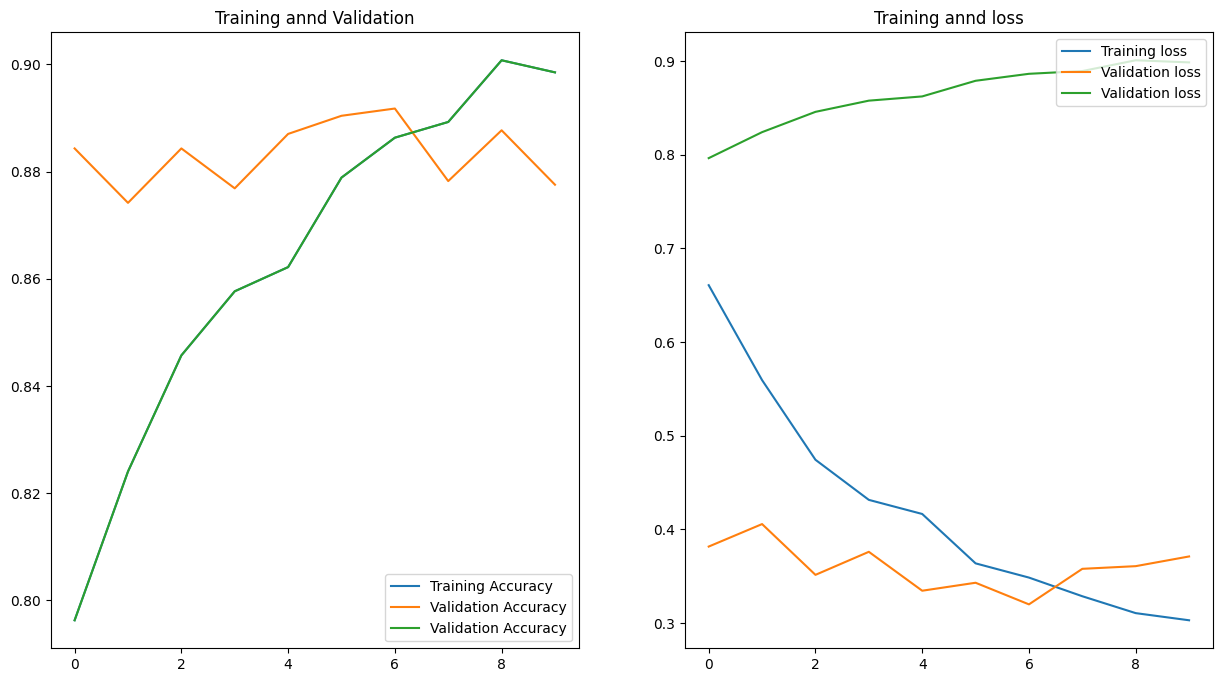

In [42]:
epochs_range=range(10)
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training Accuracy')
plt.plot(epochs_range,val_acc,acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training annd Validation')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Training loss')
plt.plot(epochs_range,val_loss,acc,label='Validation loss')
plt.legend(loc='upper right')
plt.title('Training annd loss')

In [43]:
model.evaluate(X_test,y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.8816 - loss: 0.3822


[0.38217976689338684, 0.8815967440605164]

In [44]:
y_pred=model.predict(X_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step
